# Download data (skips if data is already there

In [1]:
%run scripts/download_data.py

Skipping part1.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part1.tar.gz
Skipping part2.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part2.tar.gz
Skipping part3.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part3.tar.gz
Done.


# Unzip files  - skip if raw data directories already exist

In [4]:
import os

# Check if the folder is empty; if so, extract the files
if os.path.isdir("data/raw/utkface/part1"):
    print("Already extracted part1, skipping.")
else:
    !tar -xzf data/raw/utkface/part1.tar.gz -C data/raw/utkface

if os.path.isdir("data/raw/utkface/part2"):
    print("Already extracted part2, skipping.")
else:
    !tar -xzf data/raw/utkface/part2.tar.gz -C data/raw/utkface

if os.path.isdir("data/raw/utkface/part3"):
    print("Already extracted part3, skipping.")
else:
    !tar -xzf data/raw/utkface/part3.tar.gz -C data/raw/utkface


Already extracted part1, skipping.
Already extracted part2, skipping.
Already extracted part3, skipping.


# Preprocess data

In [5]:
%run scripts/preprocess_data.py

Reproducibility: Random seed set to 42
RAW_DATA_DIR exists: True
RAW_DATA_DIR path: data/raw/utkface
data/raw/utkface -> 3 files
data/raw/utkface/part1 -> 10137 files
data/raw/utkface/part2 -> 10719 files
data/raw/utkface/part3 -> 3253 files
Skipped samples: 5
Train: 19283 | Valid: 2410 | Test: 2411
Sample skipped: [('61_1_20170109142408075.jpg', 'invalid_filename'), ('61_3_20170109150557335.jpg', 'invalid_filename'), ('39_1_20170116174525125.jpg', 'invalid_filename'), ('53__0_20170116184028385.jpg', 'invalid_filename'), ('.DS_Store', 'invalid_filename')]

[train] age statistics (n=19283)
  min=1  max=116  mean=33.05  median=29.0  std=20.11

[val] age statistics (n=2410)
  min=1  max=116  mean=33.11  median=29.0  std=20.22

[test] age statistics (n=2411)
  min=1  max=116  mean=32.96  median=29.0  std=20.31


# Print selected config file

In [1]:
!cat configs/linear_classification_untrained.yaml

# Config file for ResNet18 untrained, to be used as backbone for linear classification.

experiment_name: "linear_classification_untrained"
model_name: "linear"  # linear, mlp, or mlp_dropout
seed: 42
pretrained: False
freeze_backbone: False    # Whether to fine-tune the pretrained model or just use it as a feature extractor
task: "classification"   # regression or classification
metric: "mae"             # this is the same as regression since we are treating age estimation as regression, but we will report it as MAE instead of MSE for better interpretability

# Data parameters
batch_size: 32
num_workers: 4
image_size: 224

# Training parameters
epochs: 30
learning_rate: 0.001
optimizer: "Adam"
#loss_function: "CrossEntropyLoss" unsed since we set it in train.py based on task
save_best: True
weight_decay: 0.01

# MLP + Dropout
dropout: 0.2


# Train randomly initialized ResNet18

Reproducibility: Random seed set to 42
Pipeline Initialized. Loading data and model...
Using AdamW optimizer with weight decay: 0.01
Setup complete! Ready to begin training epochs.


100%|#############################################################################################################################################| 76/76 [00:32<00:00,  2.34it/s, loss=4]


Epoch [1/30] Train Loss: 4.0863, Train MAE: 15.1686, Train MSE: 385.8282, Train Acc@3: 0.1329, Train Acc@5: 0.2271 | Val Loss: 4.0041, Val MAE: 14.1639, Val MSE: 370.6527, Val Acc@3: 0.1730, Val Acc@5: 0.2851, Val MAE: 14.1639


100%|##########################################################################################################################################| 76/76 [00:32<00:00,  2.37it/s, loss=3.88]


Epoch [2/30] Train Loss: 3.9455, Train MAE: 14.3733, Train MSE: 354.8110, Train Acc@3: 0.1556, Train Acc@5: 0.2583 | Val Loss: 3.8839, Val MAE: 13.9616, Val MSE: 345.4602, Val Acc@3: 0.1772, Val Acc@5: 0.2863, Val MAE: 13.9616


...

Epoch [28/30] Train Loss: 0.5441, Train MAE: 1.4987, Train MSE: 13.8471, Train Acc@3: 0.8596, Train Acc@5: 0.9215 | Val Loss: 6.2198, Val MAE: 8.0277, Val MSE: 141.9432, Val Acc@3: 0.3311, Val Acc@5: 0.4772, Val MAE: 8.0277


100%|##########################################################################################################################################| 76/76 [00:31<00:00,  2.38it/s, loss=6.22]


Epoch [29/30] Train Loss: 0.4729, Train MAE: 1.3385, Train MSE: 11.9206, Train Acc@3: 0.8768, Train Acc@5: 0.9297 | Val Loss: 6.2182, Val MAE: 7.8157, Val MSE: 138.9069, Val Acc@3: 0.3589, Val Acc@5: 0.5021, Val MAE: 7.8157


100%|##########################################################################################################################################| 76/76 [00:32<00:00,  2.34it/s, loss=6.39]


Epoch [30/30] Train Loss: 0.4198, Train MAE: 1.1904, Train MSE: 10.4753, Train Acc@3: 0.8912, Train Acc@5: 0.9395 | Val Loss: 6.3896, Val MAE: 8.1868, Val MSE: 148.4545, Val Acc@3: 0.3407, Val Acc@5: 0.4880, Val MAE: 8.1868
Saving Best Val MAE: 6.6537 at Epoch 30
Saved model with MAE = 6.6537
Saved training stats history to /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/outputs/stats_history_linear_classification_untrained.npy
Training completely finished! Best Val Loss: 3.2209, Best Val MAE: 6.6537


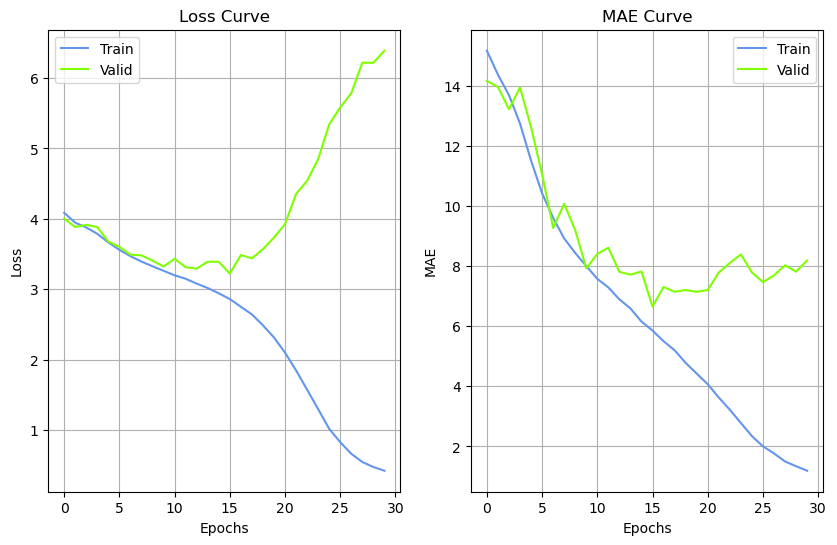

In [2]:
%run scripts/train.py --config configs/linear_classification_untrained.yaml

# Evaluate randomly initialized ResNet18

In [4]:
%run scripts/evaluate.py --config configs/linear_classification_untrained.yaml

Reproducibility: Random seed set to 42
Configuration loaded. Loading data and model...
Loading model from checkpoint: /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/outputs/checkpoint_linear_classification_untrained.pth


100%|##########################################################################################################################################| 76/76 [00:32<00:00,  2.37it/s, loss=3.21]


Evaluation Metrics — linear_classification_untrained
+--------+----------+
| Metric |    Value |
+--------+----------+
| MAE    |   6.9176 |
| MSE    | 106.8832 |
| Acc@3  |   0.3774 |
| Acc@5  |   0.5355 |
+--------+----------+


# Plot validation curves

Epochs 0-10: Best Val MAE = 7.9249
Epochs 0-20: Best Val MAE = 6.6537
Epochs 0-30: Best Val MAE = 7.2047


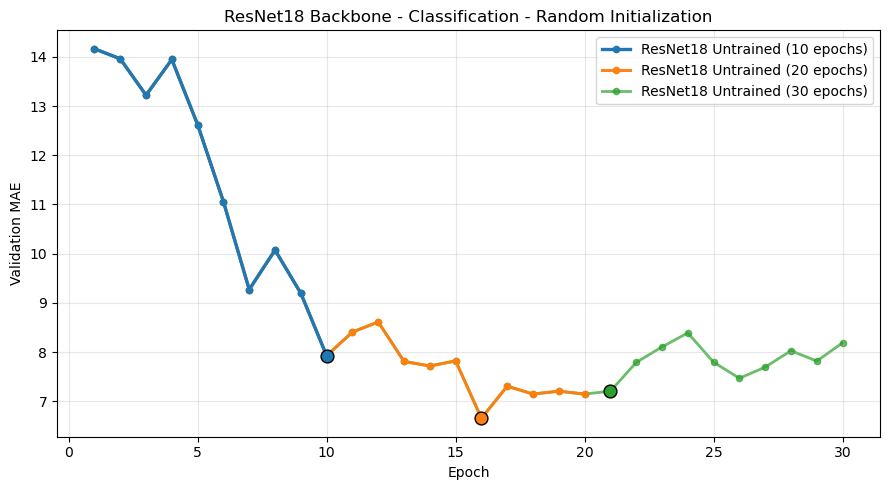

In [3]:
import numpy
from src.utils.plots import plot_validation_curves
# Load the file into a variable
data = numpy.load('outputs/stats_history_linear_classification_untrained.npy', allow_pickle=True).item()

plot_validation_curves(data['eval'], title='ResNet18 Backbone - Classification - Random Initialization', label='ResNet18 Untrained')